# Ch4.모델 훈련

모델이 어떻게 작동하는지 잘 이해하고 있으면 적절한 모델, 올바른 훈련 알고리즘, 작업에 맞는 좋은 하이퍼파라미터를 빠르게 찾을 수 있다. 또한 디버깅이나 에러를 효율적으로 분석하는데 도움이 된다. 이 장에서 언급하는 대부분의 주제는 신경망을 이해하고 구축하고 훈련시키는 데 필수이다.

먼저 가장 간단한 모델인 선형 회귀부터 시작한다. 이 모델을 훈련시키는 두 가지 방법을 설명한다.

- 닫힌 형태의 방정식(Closed-form equation)을 사용하여 훈련 세트에 가장 잘 맞는 모델 파라미터, 즉 훈련 세트에 대해 비용 함수를 최소화하는 모델 파라미터를 직접 계산한다.  

- **경사하강법(Gradient Descent,GD)** 이라 불리는 반복적인 최적화 방식을 사용하여 모델 파라미터를 조금씩 바꾸면서 비용 함수를 최소화시킨다. 신경망에선 이를 변형한 Batch 경사하강법, Mini-batch 경사하강법, 확률적 경사하강법(SGD)를 사용한다.

결국에는 방정식과 경사하강법 모두 동일한 파라미터로 수렴하게 될 것이다.

그 다음엔 비선형 데이터셋에서 훈련시킬 수 있는 조금 더 복잡한 모델인 다항 회귀를 살펴본다. 다항 회귀는 선형 회귀보다 파라미터가 많아 훈련 데이터에 과대적합되기 더 쉬우므로, 학습 곡선(Learning curve)을 사용해 모델이 과대적합되는지 감지하는 방법도 살펴본다. 그런 다음 훈련 세트의 과대적합을 줄일 수 있는 규제 기법을 몇 가지 알아본다.

마지막으로 분류 작업에 자주 사용되는 로지스틱 회귀와 소프트맥스(Softmax) 회귀를 살펴본다.

---

## 4.1 선형 회귀

다음은 1장에서 살펴본 삶의 만족도에 대한 간단한 선형 회귀 모델이다.
$$
Satisfaction\ =\ \theta_0+\theta_1 \times GDP
$$


이 모델은 입력 변수인 1인당 GDP에 대한 선형 함수이다. $\theta_0$과 $\theta_1$이 모델 파라미터이다. $\theta$ 말고 $\beta$로 표현하기도 한다.

더 일반적으로 선형 모델은 다음과 같이 $n$개의 입력 변수의 가중치(계수) 합과 절편(또는 편향)이라는 상수를 더해 예측을 만든다.
$$
\hat{y}=\theta_0+\theta_1x_1+\theta_2x_2+\cdots +\theta_n x_n
$$

이 식은 다음과 같이 벡터 형태로 더 간단하게 쓸 수 있다.
$$
\hat{y}=h_{\theta}(\boldsymbol{X})=\boldsymbol{\theta}\boldsymbol{X}
$$

<center>

| Notations | 설명 |
|:---------:|:---:|
|$h_{\theta}$|모델 파라미터 $\theta$를 사용한 가설 함수 |
|$\boldsymbol{\theta}$    |절편 $\theta_0$와 나머지 변수의 가중치를 담은 파라미터 벡터 |
|$\boldsymbol{X}$| $x_0$에서 $x_n$까지 담은 샘플의 특성 벡터 ($x_0$는 항상 1)|
|$\boldsymbol{\theta X}$| 벡터 $\boldsymbol{\theta}$와 $\boldsymbol{X}$의 dot product |

</center>

머신러닝에서는 종종 벡터를 하나의 열을 가진 2D 배열인 **열 벡터**로 나타낸다. $\boldsymbol{\theta}$와 $\boldsymbol{X}$가 열 벡터라면 예측은 $\hat{y}=\boldsymbol{\theta^TX}$이다. 물론 예측 결과는 같다.

이제 모델을 훈련시켜본다. 먼저 모델이 훈련 데이터에 얼마나 잘 들어맞는지 측정해야 한다. 2장에서 언급했듯이, 회귀에 가장 널리 사용되는 성능 측정 지표는 평균 제곱근 오차 $RMSE$이다. 그러므로 선형 회귀모델을 훈련시키려면 $RMSE$를 최소화하는 $\boldsymbol{\theta}$를 찾아야 한다. 실제로는 $RMSE$보단 $MSE$를 최소화하는 것이 같은 결과를 내면서 더 간단하다.

훈련 세트 $\boldsymbol{X}$에 대한 선형 회귀 가설 $h_{\theta}$의 $MSE$는 다음과 같이 계산한다.
$$
MSE(\boldsymbol{\theta}) = \frac{1}{m}\sum_{i=1}^{m}(\boldsymbol{\theta^T}X^{(i)}-y^{(i)})^2
$$

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● Caution</strong><br>
    학습 알고리즘은 종종 최종 모델을 평가하는 데 사용되는 성능 지표와 다른 손실 함수를 훈련 중에 최적화한다. 이는 일반적으로 해당 함수가 최적화하기 더 쉽거나 훈련 중에만 필요한 추가 항이 있기 때문이다. 예를 들어 분류기는 종종 로그 손실과 같은 비용 함수를 사용하여 학습되지만 정밀도와 재현율을 사용하여 평가된다. 로그 손실은 최소화하기 쉬우며, 일반적으로 로그 손실의 최소화로 정밀도와 재현율이 향상된다.
</div>

### 정규 방정식

비용 함수를 최소화하는 $\boldsymbol{\theta}$ 값을 찾기 위해 결과를 바로 얻을 수 있는 공식이 있다. 이를 **정규 방정식(Normal equation)** 이라고 한다.
$$
\boldsymbol{\hat\theta}=(X^TX)^{-1}X^TY
$$

<center>

| Notations | 설명 |
|:--------: |:---:|
| $\boldsymbol{\hat\theta}$ | 비용함수를 최소화하는 $\boldsymbol{\theta}$ |
|        $Y$     | $y^{(1)}$부터 $y^{(m)}$까지 포함하는 타겟 벡터 |

</center>

이 공식을 테스트하기 위해 선형처럼 보이는 데이터를 생성해본다.

In [1]:
import numpy as np

np.random.seed(42)
m = 100
X = 2 * np.random.rand(m,1)
y = 4 + 3 * X + np.random.randn(m,1)

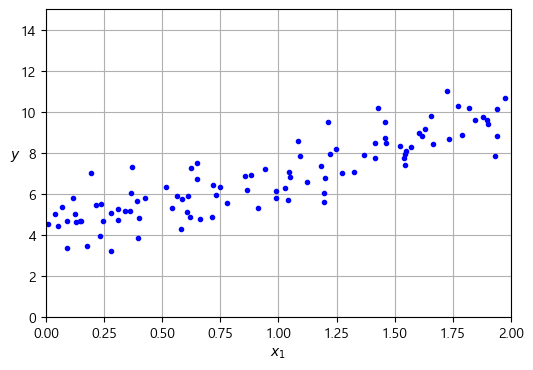

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rc('font', family='Malgun Gothic')  
plt.rcParams['axes.unicode_minus'] = False 


plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

이제 정규 방정식으로 사용해 $\boldsymbol{\hat\theta}$를 게산해본다. 넘파이 선형대수 모듈 `np.linalg`에 있는 `inv()` 함수를 사용해 역행렬을 계산하고 `dot()` 메서드를 사용해 행렬 곱을 한다.

In [3]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)    ##각 샘플에 X_0 = 1을 추가한다.
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● @ 연산자</strong><br>
    @ 연산자는 행렬 곱셈을 수행한다. A와 B가 넘파이 배열인 경우, A @ B는 <code>np.matmul(A,B)</code>와 동일하다. 텐서플로, 파이토치 등 많은 라이브러리에서도 @ 연산자를 지원한다. 순수 파이썬 배열에는 @ 연산자를 사용할 수 없다.
</div>

데이터를 생성하기 위해 사용된 함수는 $y=4+3x_1+Gaussian Noise$이다. 정규 방정식으로 계산한 값을 확인해본다.

In [4]:
print(theta_best)

[[4.21509616]
 [2.77011339]]


매우 비슷하지만 잡음 때문에 원래 함수의 파라미터를 정확하게 재현하지 못했다. 데이터셋이 작고 잡음이 많을수록 정확한 값을 얻기 힘들다. $\boldsymbol{\hat\theta}$를 사용해 예측을 해본다.

In [5]:
X_new = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

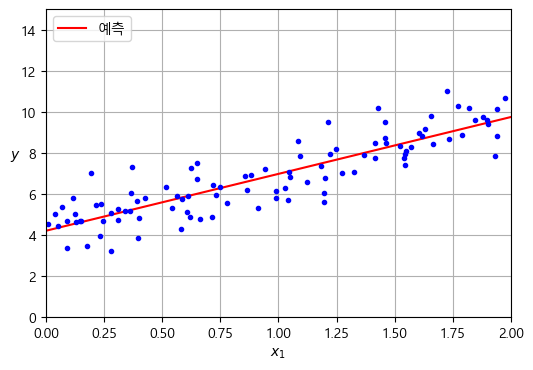

In [6]:
plt.figure(figsize=(6, 4))  
plt.plot(X_new, y_predict, "r-", label="예측")
plt.plot(X, y, "b.")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
plt.show()

사이킷런에서 선형 회귀를 수행하는 것은 매우 간단하다.

In [7]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y);
print(lin_reg.intercept_,lin_reg.coef_)
print(lin_reg.predict(X_new))

[4.21509616] [[2.77011339]]
[[4.21509616]
 [9.75532293]]


사이킷런은 변수의 가중치 `coef_`와 절편 `intercept_`를 분리하여 저장한다. `LinearRegression` 클래스는 `scipy.linalg.lstsq()` 함수를 기반으로 한다. 다음과 같이 이 함수를 직접 호출할 수 있다.

In [8]:
theta_best_svd, residuals, rank, s =np.linalg.lstsq(X_b,y,rcond=1e-6)
print(theta_best_svd)

[[4.21509616]
 [2.77011339]]


이 함수는 $\boldsymbol{\hat\theta}=X^{+}\boldsymbol{y}$를 계산한다. 여기에서 $X^{+}$는 $X$의 **무어-펜로즈 유사역행렬(Pseudo-inverse)** 이다. `np.linalg.pinv()` 함수를 사용해 유사역행렬을 직접 구할 수 있다.

In [9]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

유사역행렬 자체는 **특이값 분해(Singular Value Decomposition,SVD)** 라 부르는 표준 행렬 분해 기법을 사용해 계산된다. SVD는 훈련 세트 행렬 $X$를 3개의 행렬 곱셈 $V\Sigma^{+}U^{T}$로 분해한다. `np.linalg.svd()` 함수를 사용하여 특이값 분해를 수행할 수 있다.

유사역행렬은 $X^{+}=V\Sigma^{+}U^{T}$로 계산된다. $\Sigma^{+}$를 계산하기 위해 알고리즘이 먼저 $\Sigma$를 구한 다음 어떤 낮은 임계값보다 작은 모든 수를 0으로 바꾼다. 그 다음 0이 아닌 모든 값을 역수로 치환한다. 마지막으로 만들어진 행렬을 전치한다. 정규 방정식을 계산하는 것보다 이 방식이 훨씬 효율적이다. 또한 극단적인 경우도 처리할 수 있다.  
실제로 $m \lt n$이거나 어떤 변수가 중복되어 행렬 $X^{T}X$의 역행렬이 없다면 ($Det(X)$가 0이거나 거의 0인 경우) 정규 방정식이 작동하지 않는다. 하지만 유사역행렬은 항상 구할 수 있다.

### 계산복잡도

정규 방정식은 $(n+1) \times (n+1)$ 크기의 $X^{T}X$의 행렬을 계산한다($n$은 변수의 수). 역행렬을 계산하는 계산 복잡도는 일반적으로 $O(n^{2.4})$에서 $O(n{3})$ 사이이며, 구현 방법에 따라 차이가 존재한다. 이는 변수의 수가 두 배로 늘어나면 계산 시간이 대략 $2^{2.4}=5.3$에서 $2^3=8$배로 증가한다는 의미이다.

사이킷런의 `LinearRegression` 클래스가 사용하는 SVD 방법은 약 $O(n^2)$이다. 변수의 개수가 두 배로 늘어나면 계산 시간은 대략 4배가 된다.

또한 정규 방정식이나 다른 알고리즘으로 학습된 선형 회귀 모델은 예측이 매우 빠르다. 예측 계산 복잡도는 샘플 수와 변수의 수에 선형적이다. 다시 말해 예측하려는 샘플이나 변수가 두 배로 증가하면 걸리는 시간도 거의 두 배 증가한다.

---

## 4.2 경사 하강법

**경사하강법(Gradient Descent)** 은 여러 종류의 문제에서 최적의 해법을 찾을 수 있는 일반적인 최적화 알고리즘이다. 경사하강법의 기본 아이디어를 비용 함수를 최소화하기 위해 반복해서 파라미터를 조정하는 것이다.

짙은 안개 때문에 산속에서 길을 잃었다고 생각해보자. 발밑 지면의 기울기만 느낄 수 있다. 빨리 골짜기로 내려가는 좋은 방법은 가장 가파른 길을 따라 아래로 내려가는 것이다. 이것이 바로 경사하강법의 원리이다. 파라미터 벡터 $\boldsymbol{\theta}$에 대해 비용 함수의 현재 그래디언트를 계산한다. 그리고 그래티언트가 감소하는 방향으로 진행하며, 0이 되면 최소값에 도달한 것이다.

구체적으로 보면 $\boldsymbol{\theta}$를 임의의 값으로 시작해서 (랜덤 초기화) 한 번에 조금씩 비용 함수가 감소되는 방향으로 진행하여 알고리즘이 최소값에 수렴할 때까지 점진적으로 향상시킨다.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# 최적화할 함수: f(x) = x^2
def f(x):
    return x**2

# f(x)의 미분 (gradient): f'(x) = 2x
def grad_f(x):
    return 2*x

In [12]:
# 초기값, 학습률, 반복 횟수
x = -10  # 초기값
learning_rate = 0.1
x_history = [x]

# 경사하강법 반복
for _ in range(25):
    x = x - learning_rate * grad_f(x)
    x_history.append(x)

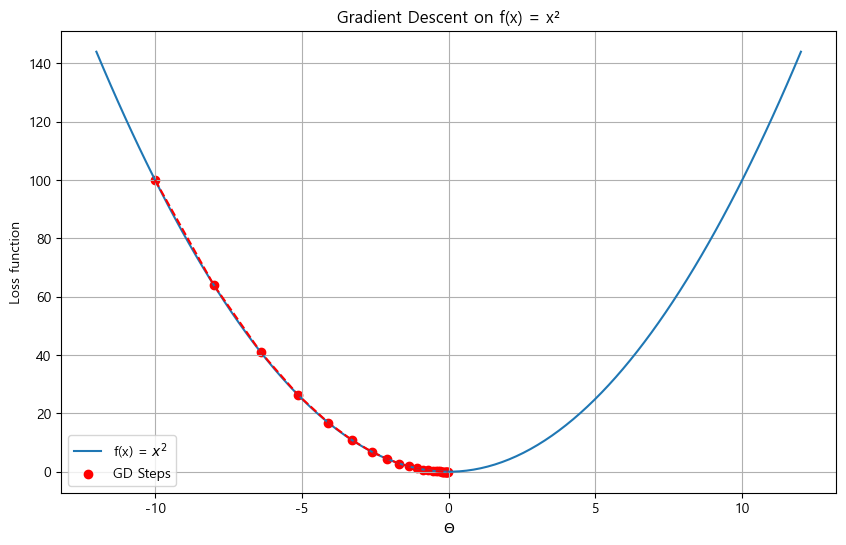

In [13]:
# x 축 범위 설정
x_vals = np.linspace(-12, 12, 100)
y_vals = f(x_vals)

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = $x^2$')
plt.scatter(x_history, [f(xi) for xi in x_history], color='red', label='GD Steps')
plt.plot(x_history, [f(xi) for xi in x_history], color='red', linestyle='--')
plt.title("Gradient Descent on f(x) = x²")
plt.xlabel("$\Theta$")
plt.ylabel("Loss function")
plt.legend()
plt.grid()
plt.show()


경사 하강법에서 중요한 파라미터는 스텝의 크기로, **학습률** 하이퍼파라미터로 결정된다. 학습률이 너무 작으면 알고리즘이 수렴하기 위해 반복을 많이 진행해야 하므로 시간이 오래 걸린다.

In [14]:
x = -10  

##small_learning_rate
learning_rate = 0.01
x_history = [x]

for _ in range(25):
    x = x - learning_rate * grad_f(x)
    x_history.append(x)

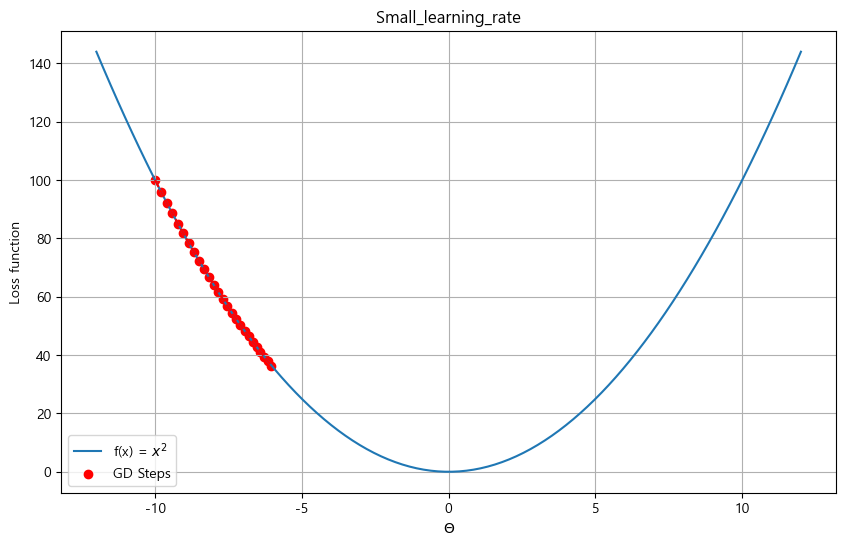

In [15]:
x_vals = np.linspace(-12, 12, 100)
y_vals = f(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = $x^2$')
plt.scatter(x_history, [f(xi) for xi in x_history], color='red', label='GD Steps')
plt.plot(x_history, [f(xi) for xi in x_history], color='red', linestyle='--')
plt.title("Small_learning_rate")
plt.xlabel("$\Theta$")
plt.ylabel("Loss function")
plt.legend()
plt.grid()
plt.show()

한편 학습률이 너무 크면 골짜기를 가로질러 반대편으로 건너뛰게 되어 이전보다 더 높은 곳으로 올라가게 될지도 모른다. 이는 알고리즘을 더 큰 값으로 발산하게 만들어 적절한 해법을 찾지 못하게 한다.

In [16]:
x = -10  

##Large_learning_rate
learning_rate = 0.99
x_history = [x]

for _ in range(25):
    x = x - learning_rate * grad_f(x)
    x_history.append(x)

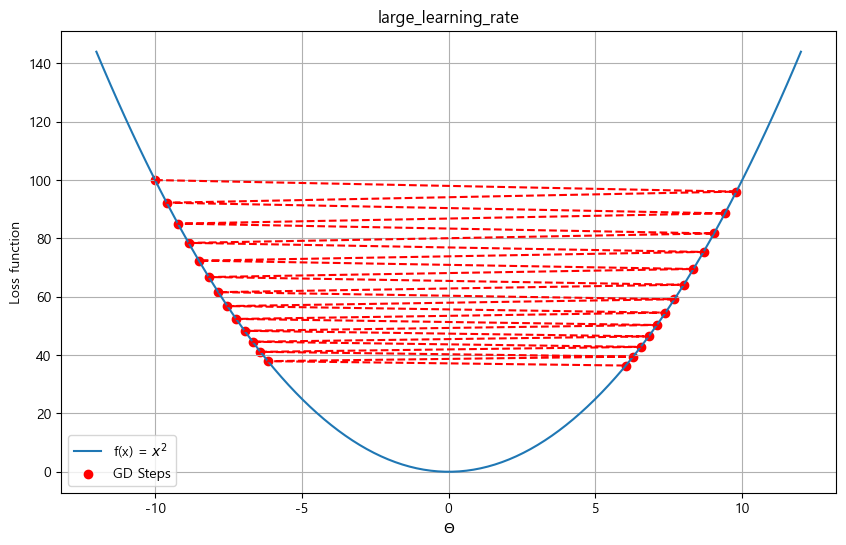

In [17]:
x_vals = np.linspace(-12, 12, 100)
y_vals = f(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = $x^2$')
plt.scatter(x_history, [f(xi) for xi in x_history], color='red', label='GD Steps')
plt.plot(x_history, [f(xi) for xi in x_history], color='red', linestyle='--')
plt.title("large_learning_rate")
plt.xlabel("$\Theta$")
plt.ylabel("Loss function")
plt.legend()
plt.grid()
plt.show()

모든 비용함수가 매끈한 그릇 형태는 아니다. 매우 울퉁불퉁한 형태를 가지고 있으면, 최소값으로 수렴하기 매우 어렵다.

다음 그림은 경사하강법의 두 가지 문제점을 보여준다. **랜덤 초기화** 때문에 알고리즘이 왼쪽에서 시작하면 **전역 최소값(global minimum)** 보다 덜 좋은 **지역 최소값(local minimum)** 에 수렴한다. 알고리즘이 오른쪽에서 시작하면 평탄한 지역을 지나기 위해 시간이 오래 걸리고 일찍 멈추게 되어 전역 최소값에 도달하지 못한다.

<center>

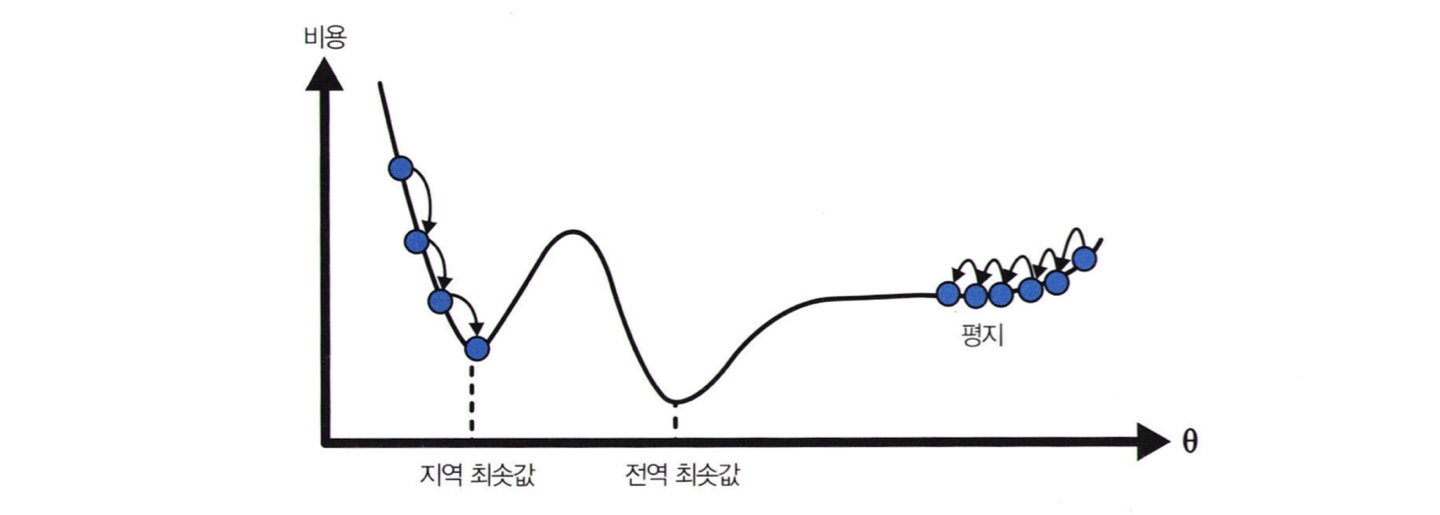

</center>

다행히 선형 회귀를 위한 $MSE$ 비용함수는 곡선에서 어떤 두 점을 선택해 선을 그어도 곡선을 가로지르지 않는 **볼록 함수(convex function)** 이다. 이는 지역 최소값이 없고 하나의 전역 최소값만 있다는 뜻이다. 또한 연속된 함수이고 기울기가 갑자기 변하지 않는다.  
이 두 사실로부터 경사하강법이 학습률이 너무 높지 않고 충분한 시간이 주어지면 전역 최소값에 가깝게 접근할 수 있다는 것을 보장한다.

사실 비용함수는 그릇 모양을 하고 있지만 변수들의 스케일이 매우 다르면 길쭉한 모양일 수 있다. 다음 그림은 변수 1과 변수 2의 스케일이 같은 훈련 세트(왼쪽)와, 변수 1이 변수 2보다 더 작은 훈련 세트(오른쪽)에 대한 경사하강법을 보여준다.

<center>

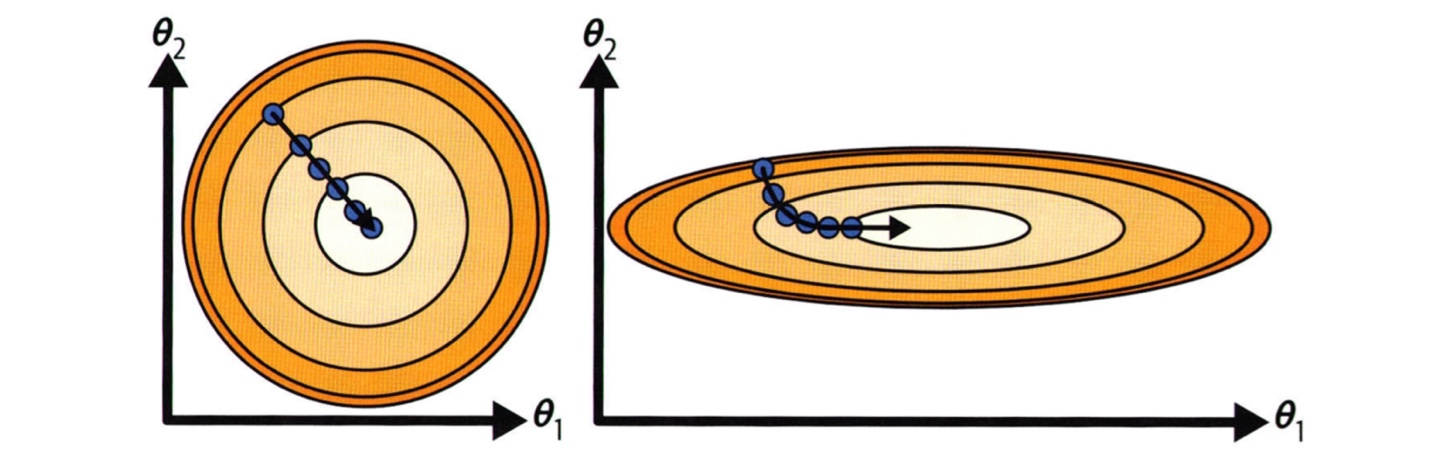

</center>

그림에서 볼 수 있듯이 왼쪽의 경사하강법 알고리즘이 최소값으로 곧장 진행하고 있어 빠르게 도달한다. 반면에 오른쪽 그래프는 처음엔 전역 최소값의 방향에 거의 직각으로 향하다가 평평한 골짜기로 길게 돌아서 나간다. 결국 최소값에 도달하겠지만, 시간이 오래 걸릴 것이다.

따라서 경사하강법을 사용할 때는 반드시 모든 변수의 스케일을 같게 만들어야 한다. 그렇지 않으면 수렴하는 데 훨씬 오래 걸린다.

또한, 위의 그림은 모델 훈련이 훈련 세트에서 비용 함수를 최소화하는 모델 파라미터의 조합을 찾는 일임을 설명해준다. 이를 모델의 **파라미터 공간**에서 찾는다고 말한다. 모델이 가진 파라미터가 많을수록 이 공간의 차원은 커지고 탐색이 더 어려워진다. 선형 회귀의 경우 비용함수가 볼록 함수이기 때문에 비교적 빨리 찾는다.

### 배치 경사 하강법

경사 하강법을 구현하려면 각 모델의 파라미터 $\theta_j$에 대해 비용함수의 그래디언트를 계산해야한다. 다시 말해 $\theta_j$가 조금 변경될 때 비용함수가 얼마나 바뀌는지 계산해야 한다. 이를 **편도함수(Partial Derivative)** 라고 한다.  
다음 식은 파라미터 $\theta_j$에 대한 비용함수의 편도함수 $\frac{\partial }{\partial \theta_j}MSE(\theta)$이다.

$$
\frac{\partial }{\partial \theta_j}MSE(\theta)=\frac{2}{m}\sum_{i=1}^{m}(\theta^TX^{(i)}-Y^{(i)})x^{(i)}_j
$$

편도함수를 각각 계산하는 대신 아래의 식을 사용하여 한번에 계산할 수도 있다. 그래디언트 벡터 $\nabla _{\theta}MSE(\theta)$는 비용함수의 편도함수를 모두 담고있다.

$$
\nabla _{\theta}MSE(\theta) = \begin{bmatrix}
\frac{\partial }{\partial \theta_0}MSE(\theta) \\
\frac{\partial }{\partial \theta_1}MSE(\theta) \\
\vdots  \\
\frac{\partial }{\partial \theta_n}MSE(\theta)
\end{bmatrix}
=
\frac{2}{m}X^T(X\theta-y)
$$

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● Caution</strong><br>
    이 공식은 매 경사하강법 스텝에서 전체 훈련 세트 X에 대해 계산한다. 이 알고리즘을 <b>배치 경사하강법(Batch gradient descent)</b>이라고 한다. 즉, 매 스텝에서 훈련 데이터 전체를 사용한다. 이런 이유로 매우 큰 훈련 세트에서는 아주 느리다. 그러나 경사하강법은 변수의 수에 민감하지 않다. 수십만 개의 변수에서 선형 회귀를 훈련시키려면 정규 방정식이나 SVD 분해보다 경사하강법을 사용하는 편이 훨씬 빠르다.
</div>

위로 향하는 그래디언트 벡터가 구해지면 반대 방향인 아래로 가야한다. $\theta$에서 $\nabla _{\theta}MSE(\theta)$를 빼야 한다는 의미이다. 여기서 학습률 $\eta$가 사용된다. 내려가는 스텝의 크기를 결정하기 위해 그래디언트 벡터에 $\eta$를 곱한다.
$$
\theta^{(next\ step)} = \theta-\eta \nabla _{\theta}MSE(\theta)
$$

이 알고리즘을 간단히 구현한다.

In [18]:
eta = 0.1
n_epochs = 1000
m = len(X_b)

np.random.seed(42)
theta = np.random.randn(2,1) #모델 파라미터를 랜덤 초기화

for epoch in range(n_epochs):
    gradients = 2/m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

In [19]:
theta

array([[4.21509616],
       [2.77011339]])

정규 방정식으로 찾은 것과 정확히 같다. 다음 그림은 세 가지 학습률을 사용하여 진행한 경사 하강법의 첫 20 스텝을 보여준다. 각 그래프에서 맨 아래 있는 선은 랜덤한 시작점을 나타내며 각 에포크는 점점 더 진한 선으로 표시된다.

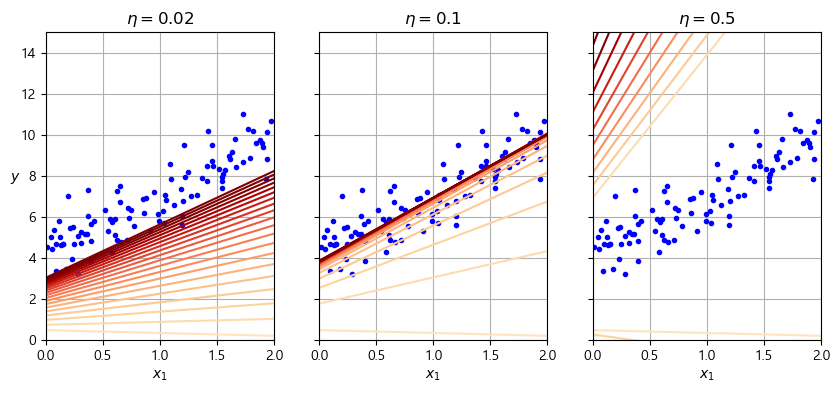

In [20]:
import matplotlib as mpl


def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # 랜덤 초기화

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
plt.show()

왼쪽은 학습률이 너무 낮다. 알고리즘은 최적점에 도달하겠지만 시간이 오래 걸릴 것이다. 가운데는 학습률이 적당해 보인다. 반복 몇 번만에 이미 최적점에 수렴했다. 오른쪽은 학습률이 너무 높다. 알고리즘이 이리저리 널뛰면서 스텝마다 최적점에서 점점 더 멀어져 발산한다.

적절한 학습률을 찾기 위해 그리드 서치를 사용한다. 하지만 그리드 서치에서 수렴하는 데 너무 오래 걸리는 모델이 제외될 수 있도록 반복 횟수를 제한해야 한다.

반복 횟수를 지정하는 방법으로, 반복 횟수를 아주 크게 지정하고 그래디언트 벡터가 아주 작아지면, 즉 **벡터의 노름이 허용 오차(tolerance)보다 작아지면** 경사하강법이 최소값에 도달하는 것이므로 알고리즘을 중지하는 것이다.

### 확률적 경사 하강법

배치 경사하강법은 매 스텝마다 전체 훈련 세트를 사용해 그래디언트를 계산하므로, 훈련 세트가 커지면 매우 느려진다. 이와 반대로, **확률적 경사하강법(Stochastic GD)** 은 매 스텝에서 한 개의 샘플을 랜덤으로 선택하고 하나의 샘플에 대한 그래디언트를 계산한다. 한 번에 하나의 샘플을 랜덤으로 선택하고 그 하나의 샘플에 대한 그래디언트를 계산한다. 한 번에 하나의 샘플을 처리하면 매 반봇에서 다뤄야할 데이터가 매우 적기 때문에 알고리즘이 훨씬 빠르다. 또한 매 반복에서 하나의 샘플만 메모리에 있으면 되므로 매우 큰 훈련 세트도 훈련시킬 수 있다.

하지만 확률적, 즉 랜덤이므로 배치 경사하강법보다 불안정하다. 다음 그림을 보면 비용 함수가 최소값에 다다를 때까지 **부드럽게 감소하지 않고 요동치며 평균적으로 감소**한다. 시간이 지나면 최소값에 매우 근접하하겠지만 계속 요동치며 최소값에 안착하지 못한다. 알고리즘이 멈추면 좋은 파라미터가 구해지지만 최적치는 아니다. 하지만 비용 함수가 매우 불규칙할 때 알고리즘이 지역 최소값을 건너뛰도록 도와주므로 확률적 경사하강법이 배치 경사하강법보다 전역 최소값을 찾을 가능성이 높다.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 함수 및 그래디언트 정의
def f(x, y):
    return (x - 3)**2 + (y + 1)**2

def grad_f(x, y):
    return np.array([2*(x - 3), 2*(y + 1)])


In [22]:
#SGD 파라미터 설정
lr = 0.1
steps = 20
x0 = np.array([0.0, 0.0])  # 초기값
positions = [x0]

In [23]:
x = x0.copy()
for i in range(steps):
    grad = grad_f(x[0], x[1])
    x = x - lr * grad + np.random.normal(0, 0.1, 2)  # 약간의 noise 추가 (확률적 느낌)
    positions.append(x.copy())

positions = np.array(positions)

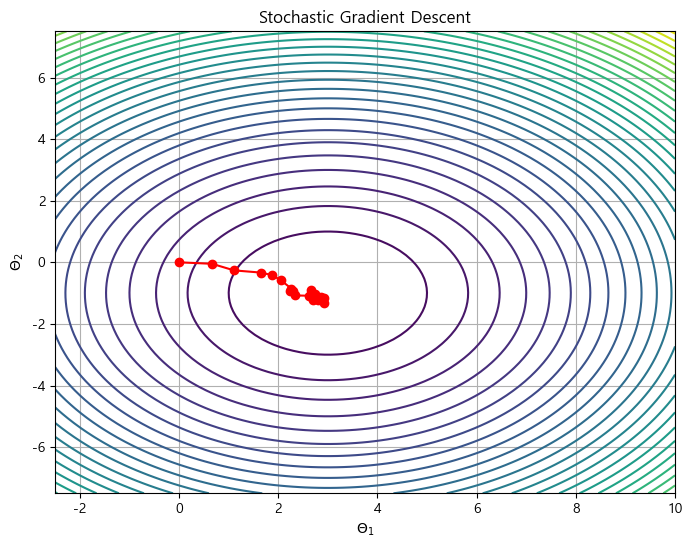

In [24]:
x_vals = np.linspace(-2.5, 10, 100)
y_vals = np.linspace(-7.5, 7.5, 100)
a, b = np.meshgrid(x_vals, y_vals)
Z = f(a, b)

plt.figure(figsize=(8, 6))
plt.contour(a, b, Z, levels=30, cmap='viridis')
plt.plot(positions[:, 0], positions[:, 1], marker='o', color='r', linestyle='-')
plt.title('Stochastic Gradient Descent')
plt.xlabel('$\Theta_1$')
plt.ylabel('$\Theta_2$')
plt.grid(True)
plt.show()

무작위성(랜덤)은 지역 최소값에서 탈출할 수 있게 도와주지만, 알고리즘이 전역 최소값에 다다르지 못하게 한다는 문제점이 있다. 이런 문제점을 해결하는 한 가지 방법은 **학습률을 점진적으로 감소**시키는 것이다. 시작할 때는 학습률을 크게 하여 수렴을 빠르게 하고 지역 최소값에 빠지지 않게 하고, 점차 줄여 알고리즘이 전역 최소값에 도달하게 된다. 매 반복에서 학습률을 결정하는 함수를 **학습 스케줄(Learning schedule)** 이라고 한다.

학습률이 너무 빠르게 줄어들면 지역 최소값에 갇히거나 최소값까지 가는 중간에 멈춰버릴 수 있고, 반대로 너무 천천히 줄어들면 오랫동안 최소값 주변을 맴돌거나 훈련을 너무 일찍 중지해서 지역 최소값에 머무를 수 있다.

다음 코드는 간단한 학습 스케줄을 사용한 확률적 경사하강법의 구현이다.

In [25]:
n_epochs =50
t0,t1 = 5,50 #학습 스케줄 파라미터

def learning_schedule(t):
    return t0 / (t+t1)

#랜덤 초기화
np.random.seed(42)
theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    for iteration in range(m):
        
        
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index + 1]
        yi = y[random_index:random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)        ## SGD의 경우 m으로 나눌 필요가 없음
        eta = learning_schedule(epoch * m + iteration)  ## 학습률이 감소
        theta = theta - eta * gradients

In [26]:
theta

array([[4.21076011],
       [2.74856079]])

일반적으로 한 반복에서 훈련 세트에 있는 샘플 수($m$)만큼 되풀이되는데, 이 때 각 반복을 **에포크**라고 한다. 배치 경사 하강법 코드가 전체 훈련 세트에 대해 1000번 반복하는 동안 이 코드는 훈련 세트에서 50번만 반복하고도 매우 좋은 값에 도달했다.

다음 코드는 훈련의 첫 20개 스텝을 보여준다.

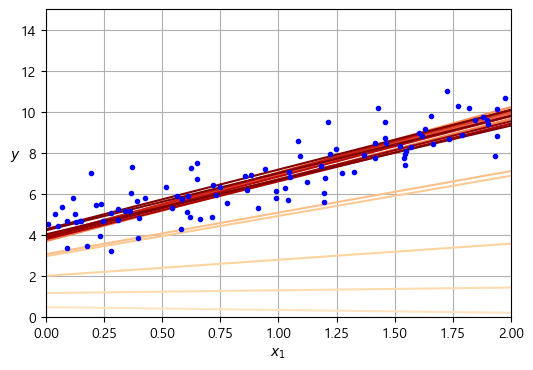

In [27]:
theta_path_sgd = []
n_epochs = 50
t0, t1 = 5, 50  # 학습 스케줄 하이퍼파라미터

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)  # 랜덤 초기화

n_shown = 20  
plt.figure(figsize=(6, 4)) 

for epoch in range(n_epochs):
    for iteration in range(m):

        if epoch == 0 and iteration < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
            plt.plot(X_new, y_predict, color=color)

        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # SGD의 경우 m으로 나누지 않음
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)  


plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

샘플을 랜덤으로 선택하기 때문에 어떤 샘플은 한 에포크에서 여러 번 선택될 수 있고 어떤 샘플은 전혀 선택되지 못할 수도 있다. 알고리즘이 에포크마다 모든 샘플을 사용하게 하려면 훈련 세트를 선택 후 (입력 변수와 레이블을 동일하게 섞어야 한다) 차례대로 하니씩 선택하고 다음 에포크에서 다시 섞는 방법을 사용할 수 있다. 하지만 이 방식은 더 복잡하고 일반적으로 결과가 더 향상되지는 않는다.

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● Caution</strong><br>
    확률적 경사하강법을 사용할 때 훈련 샘플이 독립적이고, 동일한 분포를 따른다는 <b>IID(Independent & Identically Distributed)</b> 가정을 만족해야 평균적으로 파라미터가 전역 최적점을 향해 진행한다고 보장할 수 있다. 이렇게 만드는 간단한 방법은 훈련하는 동안 샘플을 섞는 것이다. 만약 레이블 순서대로 정렬된 샘플처럼 샘플을 섞지 않은 채로 사용하면 확률적 경사하강법이 먼저 한 레이블을 최적화한 다음 두 번째 레이블을 최적화하는 방식으로 진행된다. 결국 이 모델을 최적점에 가깝게 도달하지 못한다.
</div>

사이킷런에서 SGD 방식으로 선형 회귀를 사용하려면 기본값으로 제곱 오차 비용 함수를 최적화하는 `SGDRegressor` 클래스를 사용한다. 다음 코드는 최대 1000번 에포크 (`max_iter`)동안 실행된다. 또는 100번 에포크(`n_iter_change`) 동안 손실이 $10^{-5}$(`tol`)보다 작아질 때까지 실행된다. 학습률 0.01 (`eta0`)로 기본 학습 스케줄을 사용한다.

In [28]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol= 1e-5,penalty=None,eta0=0.01,
                       n_iter_no_change=100,random_state=42)

sgd_reg.fit(X,y.ravel()); #fit()이 1D 타겟을 기대하기 때문에 y.ravel()로 사용

In [29]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● TIP</strong><br>
    모든 사이킷런 추정기는 <code>fit()</code> 메서드를 사용하여 훈련할 수 있지만 일부 추정기는 <code>partial_fit()</code> 메서드를 사용해 하나 이상의 샘플에서 한 번의 반복 훈련을 실행할 수 있다. 이 경우, 하이퍼파라미터는 무시된다. <code>partial_fit()</code>를 반복적으로 호출하면 모델이 점진적으로 훈련된다. 이 기능은 훈련 과정을 더 세밀하게 제어해야 할 때 유용하다. 다른 모델에는 대신 <code>warm_start</code> 하이퍼파라미터가 있다. <code>warm_start=True</code>로 설정하면 훈련된 모델에서 <code>fit()</code> 메서드를 호출해도 모델이 재설정되지 않고 <code>max_iter</code> 및 <code>tol</code>과 같은 하이퍼파라미터를 반영하여 중지된 지점부터 계속 훈련한다. <code>fit()</code>은 학습 스케줄에 사용되는 반복 카운터를 재설정하지만 <code>partial_fit()</code>는 재설정하지 않는다.
</div>

### 미니배치 경사 하강법

마지막으로 살펴볼 경사하강법 알고리즘은 **미니배치 경사하강법(mini-batch GD)** 이다. 각 스텝에서 전체 훈련 세트나 하나의 샘플을 기반으로 그래디언트를 계산하는 것이 아니라, **미니배치**라 부르는 임의의 작은 샘플 세트에 대해 그래디언트를 계산한다. 확률적 경사하강법에 비해 미니배치 경사하강법의 주요 장점은 행렬 연산에 최적화된 하드웨어, 특히 GPU를 사용해서 성능을 향상시킬 수 있다는 점이다.

특히 미니배치를 어느 정도 크게 하면 알고리즘은 파라미터 공간에서 SGD보다 덜 불규칙하게 움직인다. 결국 미니배치 경사하강법이 SGD보다 최소값에 더 가까이 도달하게 될 것이다. 하지만 MSE 비용함수를 사용하는 선형회귀가 아닌 지역 최소값이 문제가 되는 경우엔 지역 최소값에서 빠져나오기 더 힘들수도 있다.

다음 그림은 세 가지 경사하강법 알고리즘이 훈련 과정 동안 파라미터 공간에서 움직인 경로이다.

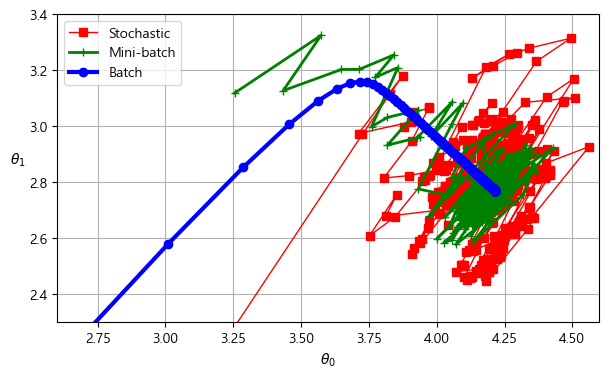

In [30]:
from math import ceil

n_epochs = 50
minibatch_size = 20
n_batches_per_epoch = ceil(m / minibatch_size)

np.random.seed(42)
theta = np.random.randn(2, 1)  # 랜덤 초기화

t0, t1 = 200, 1000  # 학습 스케줄 하이퍼파라미터

def learning_schedule(t):
    return t0 / (t + t1)

theta_path_mgd = []
for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * minibatch_size
        xi = X_b_shuffled[idx : idx + minibatch_size]
        yi = y_shuffled[idx : idx + minibatch_size]
        gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(iteration)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(7, 4))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1,
         label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2,
         label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3,
         label="Batch")
plt.legend(loc="upper left")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$   ", rotation=0)
plt.axis([2.6, 4.6, 2.3, 3.4])
plt.grid()
plt.show()

모두 최소값 근처에 도달했지만 배치 경사하강법이 최소값에서 멈춘 반면, 확률적,미니배치 경사하강법은 근처에서 맴돌고 있다. 그렇지만 배치 경사하강법의 경우 매 스텝에서 많은 시간이 소요되며 확률적 경사하강법과 미니배치 경사하강법의 경우에도 적절한 학습 스케줄을 사용하면 최소값에 도달한다.

### 선형 회귀 알고리즘 정리

지금까지 논의한 알고리즘을 비교한다. $m$은 훈련 샘플의 수이고 $n$은 변수의 수이다.

<center>

| 알고리즘 | $m$이 클 때 | 외부 메모리 학습 지원 | n이 클 때 | 하이퍼파라미터 수 | 스케일 조정 필요 | 사이킷런 |
|:------:|:-----------:|:------------------:|:--------:|:--------------:|:--------------:|:-------:|
| 정규 방정식 | 빠름 | No | 느림 | 0 | No | `N/A` |
| SVD | 빠름 | No | 느림 | 0 | No | `LinearRegression` |
| 배치 경사하강법 | 느림 | No | 빠름 | 2 | Yes | `N/A` |
| 확률적 경사하강법 | 빠름 | Yes | 빠름 | $\ge 2$ | Yes | `SGDRegressor` |
| 미니배치 경사하강법 | 빠름 | Yes | 빠름 | $\ge 2$ | Yes | `N/A` |

</center>

---

## 4.3 다항 회귀

비선형 데이터를 학습하는 데 선형 모델을 사용할 수 있다. 각 변수의 **거듭제곱을 새로운 변수로 추가**하고 이렇게 확장된 변수를 포함한 데이터셋에 선형 모델을 훈련시키면 된다. 이를 **다항 회귀(Polynomial regression)** 라고 한다.

예시로, 먼저 $y=ax^2+bx+c$인 간단한 2차 방정식에 잡음을 추가한 비선형 데이터를 생성한다.

In [31]:
np.random.seed(42)
m = 100
X = 6*np.random.rand(m,1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m,1)

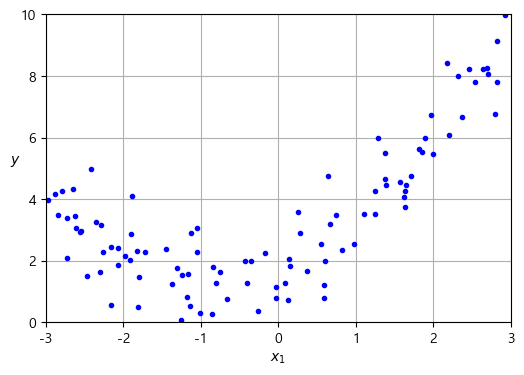

In [32]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

직선은 이 데이터에 맞지 않으므로, 사이킷런의 `PolynomialFeatures`를 사용해 훈련 데이터를 변환한다. 훈련 세트에 있는 각 변수를 제곱하여 새로운 변수로 추가한다.

`PolynomialFeatures`의 파라미터 `degree`의 기본값은 2이고 `include_bias`의 기본값은 `True`이다. `include_bias=True`면 편향을 위한 변수 $x_0$인 1이 추가된다.

In [33]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly_features.fit_transform(X)
print(X[0])
print(X_poly[0])

[-0.75275929]
[-0.75275929  0.56664654]


`X_poly`는 원래 변수 $X$와 이 변수의 제곱을 포함한다. 이 확장된 훈련 데이터에 `LinearRegression`을 적용해본다.

In [34]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

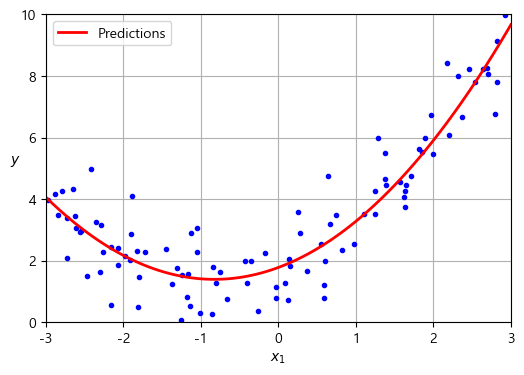

In [35]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

실제 함수가 $y=0.5x^2_1 + 1x_1 + 2 + GaussianNoise$이고 예측된 모델은 $\hat{y} = 0.56x^2_1+0.93x_1+1.78$이다.

변수가 여러 개일 때 다항회귀는 변수 사이의 관계(교호작용)를 찾을 수 있다(일반적인 선형 회귀에선 하지 못한다). `PolynomialFeatures`가 주어진 차수까지 변수 간 모든 교차항을 추가하기 때문이다. 예를 들어 두 개의 변수 $a,b$가 있을 때 `degree=3`으로 `PolynomialFeatures`를 적용하면 $a^2,a^3,b^2,b^3$ 뿐만 아니라 $ab,a^2b,ab^2$도 변수로 추가한다.

`degree=d`로 지정하면 변수가 $n$개인 배열을 변수가 $\frac{(n+d)!}{d!n!}$개인 배열로 변환한다. 따라서 변수의 수가 교차항을 포함해 급격하게 증가할 수 있고, 이는 과적합을 유발할 수 있으므로 주의해야 한다.

`PolynomialFeatures`에서 `interaction_only=True`로 지정하면 거듭제곱이 포함된 항은 모두 제외된다. `PolynomialFeatures` 객체에서 `get_features_names_out()` 메서드를 호출하면 만들어진 변수의 차수를 쉽게 확인할 수 있다.

---

## 4.4 학습 곡선

고차 다항 회귀를 적용하면 일반 선형 회귀보다 훨씬 더 훈련 데이터에 잘 맞추려 할 것이다. 다음 그림은 300차 다항 회귀 모델을 이전 훈련 데이터에 적용한 것이다. 훈련 샘플에 가능한 가까이 가려고 구불구불한 것을 볼 수 있다. 이는 심각한 과대적합이다. 반면 1차 식은 과소적합인 것을 알 수 있다.

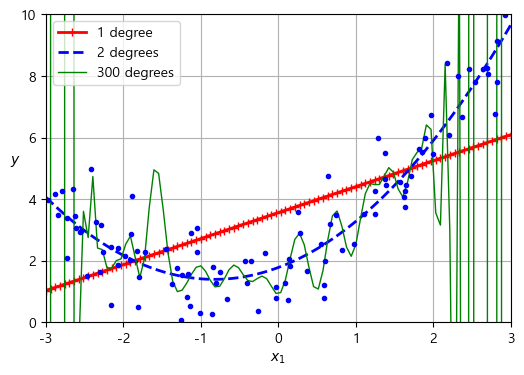

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(6, 4))

for style, width, degree in (("r-+", 2, 1), ("b--", 2, 2), ("g-", 1, 300)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

가장 일반화가 잘된 모델을 2차 다항회귀이다. 일반적으로 어떤 함수로 데이터가 생성되었는지 알 수 없다. 따라서 우리는 교차 검증을 사용하거나, **학습곡선**을 확인하여 차수를 정할 수 있다.

학습곡선은 모델의 훈련 오차와 검증 오차를 훈련 반복 횟수의 함수로 나타낸 그래프이다. 훈련하는 동안 훈련 세트와 검증 세트에서 일정한 간격으로 모델을 평가하고 그 결과를 그래프로 그리면 된다. 모델을 점진적으로 훈련할 수 없는 경우(`partial_fit()` 또는 `warm_start`를 지원하지 않는 경우) 훈련 세트의 크기를 점점 늘려가면서 여러 번 훈련해야 한다.

사이킷런에는 이를 위해 교차 검증을 사용하여 모델을 훈련하고 평가하는 `learning_curve()` 함수가 있다. 기본적으로 이 함수는 훈련 세트의 크기를 증가시키면서 모델을 재훈련하지만, 모델이 점진적 학습을 지원하는 경우 `learning_curve()`를 호출할 때 `exploit_incremental_learning=True`로 지정하면 대신 모델을 점진적으로 훈련시킨다. 이 함수는 모델을 평가한 훈련 세트 크기를 반환한다. 또한 각각의 크기와 교차 검증 폴드에서 측정한 훈련과 검증 점수를 반환한다.

`learning_curve()` 함수를 사용하여 선형 회귀 모델의 학습 곡선을 살펴본다.

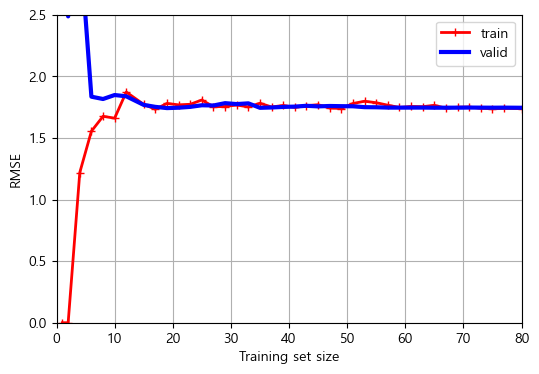

In [37]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(),X,y,train_sizes=np.linspace(0.01,1.0,40),cv=5,
    scoring='neg_root_mean_squared_error')

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)


plt.figure(figsize=(6, 4))  
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])

plt.show()

이 모델은 과소적합이다. 먼저 훈련 오차를 보면 0부터 시작하므로 훈련 세트에 하나 혹은 두 개의 샘플이 있을 땐 모델이 완벽하게 작동한다. 하지만 훈련 세트에 샘플이 추가됨에 따라 잡음도 있고 비선형이기 때문에 모델이 훈련 데이터를 완벽히 학습하는 것이 불가능해진다. 그래서 곡선이 어느 정도 평평해질 때까지 오차가 계속 상승한다. 이 위치에서는 훈련 세트에 샘플이 추가되어도 평균 오차가 크게 나아지거나 나빠지지 않는다.  
다음으로 검증 오차를 살펴본다. 모델이 적은 수의 훈련 샘플로 훈련될 때는 제대로 일반화될 수 없어서 초기에 매우 큰 오차를 보이지만 모델에 훈련 샘플이 추가되면서 학습이 되고 검증 오차가 천천히 감소한다. 하지만 선형 회귀의 직선은 데이터를 제대로 모델링할 수 없으므로 오차가 완만하게 감소하면서 훈련 세트의 그래프와 가까워진다.

해당 그래프는 과소적합 모델의 전형적인 모습이다. 두 곡선이 수평한 구간을 만들고 꽤 높은 오차에서 가까이 근접해있다. 이런 경우 훈련 샘플을 추가해도 효과가 없고 더 복잡한 모델을 사용하거나 더 나은 변수를 선택해야 한다.

이제 같은 데이터에서 10차 다항회귀모델의 학습곡선을 그려본다.

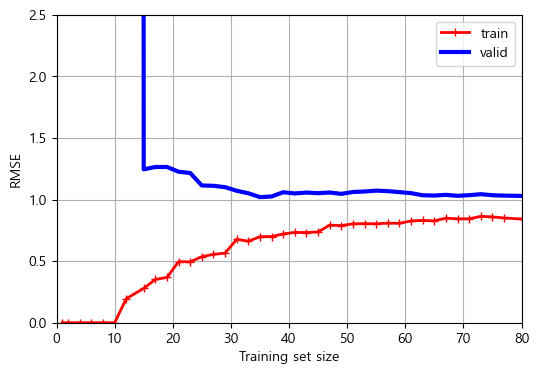

In [38]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10,include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01,1.0,40),cv=5,
    scoring="neg_root_mean_squared_error"
)

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)


plt.figure(figsize=(6, 4))  
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])

plt.show()

이 학습 곡선은 이전의 학습 곡선과 매우 중요한 차이점이 존재한다.  
- 훈련 데이터의 오차가 이전보다 훨씬 낮다.  
- 두 곡선 사이의 공간이 있다. 이는 검증 데이터에서보다 훈련 데이터에서 모델이 훨씬 더 나은 성능을 보인다는 뜻으로, **과대적합** 모델의 특징이다. 하지만 더 큰 훈련 세트를 사용하면 두 곡선이 점점 가까워진다(하지만 과대적합이 아니더라도, 일반적으로 train과 valid 의 오차에는 어느 정도 차이가 발생한다).

---

## 4.5 규제가 있는 선형 모델

과대적합을 줄이는 방법은 모델에 규제를 적용하는 것이다. 다항회귀모델을 규제하는 간단한 방법은 다항식의 차수를 줄이는 것이다.

선형회귀모델에서는 보통 모델의 가중치를 제한함으로써 규제를 가한다. 각기 다른 방법으로 가중치를 제한하는 릿지(*Ridge*), 라쏘(*Lasso*), 엘라스티넷(*Elastic-net*) 회귀를 살펴본다.

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● Caution</strong><br>
    규제가 있는 모델 대부분 입력 변수의 스케일에 민감하기 때문에 데이터의 스케일을 맞추는 것이 매우 중요하다.
</div>

### 릿지 회귀

**릿지 회귀(Ridge regression)** 또는 **티호노프 규제(Tikhonov regularization)** 는 규제가 추가된 선형회귀이다. 다음과 같은 규제항이 $MSE$에 추가된다.

$$
\frac{\alpha}{m}\sum_{i=1}^{n}\theta_i^2
$$

이는 학습 알고리즘을 데이터 맞추면서 모델의 가중치가 가능한 한 작게 유지되도록 한다. 여기서 $\boldsymbol{\alpha}$**는 규제의 강도를 조절하는 하이퍼파라미터** 이다. $\alpha=0$이면 선형 회귀와 같아지며, 반대로 매우 크면 모든 가중치가 거의 0에 가까워지고 결국 데이터의 평균을 지나는 수평선에 가까워진다.

규제항은 훈련하는 동안에만 비용함수에 추가되고, 훈련이 끝나면 모델의 성능을 규제가 없는 오차로 평가한다.

다음 식은 릿지 회귀의 비용함수이다.  
$$ 
Loss(\boldsymbol{\theta})=MSE(\boldsymbol{\theta}) +\frac{\alpha}{m}\sum_{i=1}^{n}\theta_i^2
$$

절편은 규제를 받지 않는다. $W$를 변수의 가중치 벡터 ($\theta_1$에서 $\theta_n$)라고 정의하면 규제항은 $\frac{\alpha(\left\| W \right\|_2)^2}{m}$과 같다. 여기서 $\left\| \cdot  \right\|_2$가 가중치 벡터의 $L_2\ norm$이다. 배치 경사하강법에 적용하려면 가중치에 대한 $MSE$ 그래디언트 벡터에 $\frac{2\alpha W}{m}$을 더하면 된다. 절편의 그래디언트에는 아무 것도 더하지 않는다.

다음 그림은 잡음이 많은 선형 데이터에 몇 가지 다른 $\alpha$를 사용해 릿지 모델을 학습시킨 결과이다.

In [39]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

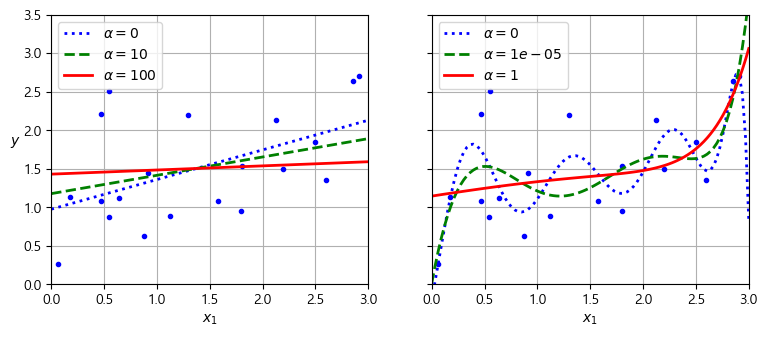

In [40]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])



def plot_model(model_class, polynomial, alphas, **model_kwargs):
    plt.plot(X, y, "b.", linewidth=3)
    for alpha, style in zip(alphas, ("b:", "g--", "r-")):
        if alpha > 0:
            model = model_class(alpha, **model_kwargs)
        else:
            model = LinearRegression()
        if polynomial:
            model = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                model)
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        plt.plot(X_new, y_new_regul, style, linewidth=2,
                 label=fr"$\alpha = {alpha}$")
    plt.legend(loc="upper left")
    plt.xlabel("$x_1$")
    plt.axis([0, 3, 0, 3.5])
    plt.grid()

plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

왼쪽 그래프는 평범한 릿지회귀를 사용해 선형적인 예측을 만들었다. 오른쪽 그래프는 `PolynomialFeatures(degree=10)`을 사용해 먼저 데이터를 확장하고 `StandardScaler()`를 사용해 스케일을 조정한 후 릿지모델을 적용했다. 이는 결국 릿지 규제를 사용한 다항회귀가 된다. $\alpha$가 증가할수록 직선에 가까워지는 것을 볼 수 있다. 즉, 모델의 분산은 줄지만 편향은 커지게 된다.

선형회귀마 마찬가지로 릿지회귀를 계산하기 위해 정규 방정식을 사용할 수도 있고 경사하강법을 사용할 수도 있다. 장단점은 이전과 같다.

다음은 릿지회귀의 정규 방정식 해이다. 여기서 $\boldsymbol{A}$는 절편에 해당하는 맨 왼쪽 위의 원소가 0인 $(n+1) \times (n+1)$ 단위행렬이다.
$$
\hat{\boldsymbol{\theta}} = (X^TX+\alpha A)^{-1}X^TY
$$

다음 코드는 사이킷런에서 정규 방정식을 사용한 릿지 회귀를 적용하는 예시이다. *Cholesky decomposition*을 사용하여 위의 식을 변형한 방정식을 사용한다.

In [41]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=0.1,solver='cholesky')  ##여기서 solver='sag'를 사용하면 확률적 평균 경사 하강법이라는 SGD의 변형을 사용한다.
ridge_reg.fit(X,y)
ridge_reg.predict([[1.5]])

array([[1.55325833]])

다음은 확률적 경사하강법을 사용했을 때이다.

In [42]:
sgd_reg = SGDRegressor(penalty='l2',alpha=0.1/ m, tol=None,
                       max_iter=1000,eta0=0.01,random_state=42)

sgd_reg.fit(X,y.ravel())
sgd_reg.predict([[1.5]])

array([1.55302613])

`penalty` 파라미터는 사용할 규제를 지정한다. `'l2'`로 지정하면 SGD가 $MSE$ 비용함수에 가중치 벡터의 $L_2\ norm$의 제곱에 `alpha`를 곱한 규제항이 추가된다. 이는 $m$으로 나누지 않는 것만 빼면 릿지회귀와 같기에, `alpha`에 `0.1/m`을 사용했다.

### 라쏘 회귀

**라쏘(Lasso) 회귀**는 선형 회귀의 또 다른 규제된 버전이다. 릿지처럼 비용함수에 규제항을 더하지만, $L_2\ norm$ 대신 가중치 벡터의 $L_1\ norm$을 사용한다. 다음은 라쏘 회귀의 비용함수이다.
$$
Loss({\boldsymbol{\theta}}) = MSE({\boldsymbol{\theta}}) + 2\alpha \sum_{i=1}^{n}\left| \theta_i \right|
$$

다음 그림은 릿지에서와 동일한 예시이지만, 라쏘모델과 여러 $\alpha$값을 사용했다.

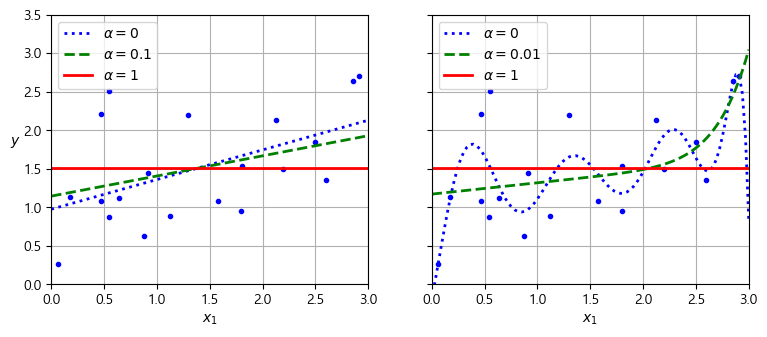

In [43]:
from sklearn.linear_model import Lasso

plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 1e-2, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

라쏘회귀의 가장 중요한 특징은, 덜 중요한 변수의 가중치를 완전히 0으로 만들어 제거할 수 있다는 점이다. 위의 그림에서 점선($\alpha=0.01$)은 3차 방정식처럼 보인다. 차수가 높은 다항변수의 가중치를 0으로 만들었기 때문이다. 릿지는 중요하지 않은 변수의 가중치를 작게 만들 순 있어도, 라쏘처럼 완전히 0으로 만들 수 없다.

라쏘회귀는 자동으로 변수를 선택하고, 0이 아닌 변수 가중치가 적은 **희소 모델(*sparse model*)** 을 만든다.

다음 그림을 보면 이를 쉽게 이해할 수 있다.

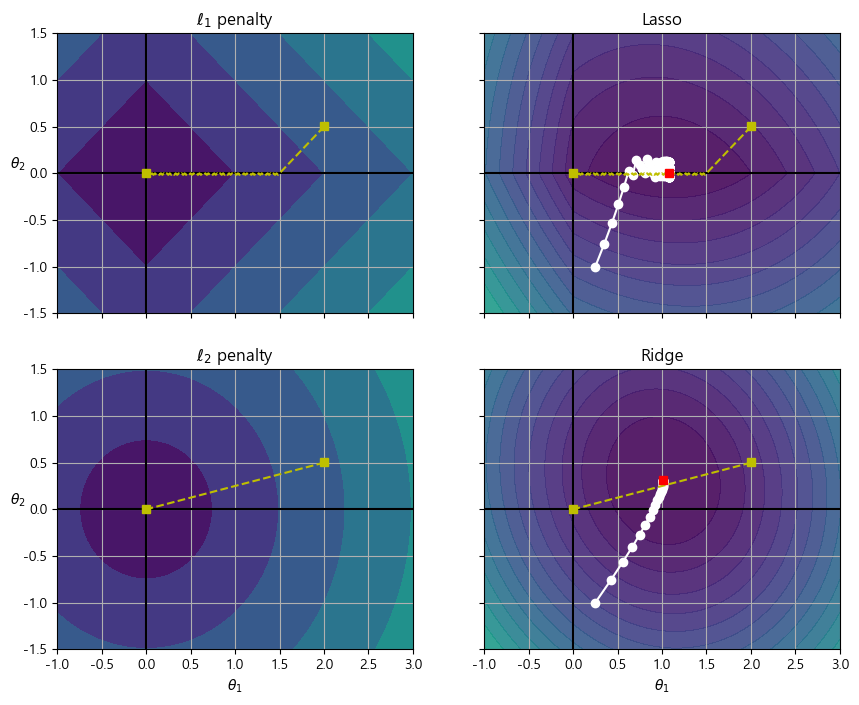

In [44]:
t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1 / len(Xr) * ((T @ Xr.T - yr.T) ** 2).sum(axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(J.argmin(), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])

def bgd_path(theta, X, y, l1, l2, core=1, eta=0.05, n_iterations=200):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = (core * 2 / len(X) * X.T @ (X @ theta - y)
                     + l1 * np.sign(theta) + l2 * theta)
        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10.1, 8))

for i, N, l1, l2, title in ((0, N1, 2.0, 0, "Lasso"), (1, N2, 0, 2.0, "Ridge")):
    JR = J + l1 * N1 + l2 * 0.5 * N2 ** 2

    tr_min_idx = np.unravel_index(JR.argmin(), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levels = np.exp(np.linspace(0, 1, 20)) - 1
    levelsJ = levels * (J.max() - J.min()) + J.min()
    levelsJR = levels * (JR.max() - JR.min()) + JR.min()
    levelsN = np.linspace(0, N.max(), 10)

    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(theta=np.array([[2.0], [0.5]]), X=Xr, y=yr,
                      l1=np.sign(l1) / 3, l2=np.sign(l2), core=0)
    ax = axes[i, 0]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, N / 2.0, levels=levelsN)
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.set_title(fr"$\ell_{i + 1}$ penalty")
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$", rotation=0)

    ax = axes[i, 1]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    ax.plot(path_JR[:, 0], path_JR[:, 1], "w-o")
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.plot(t1r_min, t2r_min, "rs")
    ax.set_title(title)
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")

plt.show()

두 축은 모델 파라미터 2개를 나타내고, 배경의 등고선은 각기 다른 손실 함수를 나타낸다.  

위의 왼쪽 그래프의 등고선은 $L_1$ 손실 $(\left| \theta_1 \right|+\left| \theta_2 \right|)$을 나타내며 축에 가까워지면서 선형적으로 줄어든다. 그래프에선 모델 파라미터를 $\theta_1=2,\theta_2=0.5$로 초기화하고 경사하강법을 실행하면 노란 점선처럼 두 파라미터가 동일하게 줄어든다. $\theta_2$가 시작할 때 0에 더 가깝기 때문에 먼저 0에 도달한다. 그 다음 경사하강법이 $\theta_1=0$에 도달할 때까지 축을 따라 내려간다.  
오른쪽 위 그래프는 $L_1$ 손실을 더한 $MSE$인 라쏘의 손실함수를 나타낸다. 하얀 선이 경사하강법으로 $\theta_1=0.25,\theta_2=-1$로 초기화된 파라미터를 최적화하는 과정을 보여준다. 여기서도 $\theta_2=0$으로 빠르게 줄어든 다음 축을 따라 진동하면서 전역 최적점인 빨간 사각형에 도달한다.  
$\alpha$가 증가하면 전역 최적점이 노란 점선을 따라 왼쪽으로 이동하고, 감소하면 전역 최적점의 오른쪽으로 이동한다.

아래의 두 그래프는 $L_2$ 손실과 릿지 손실함수를 보여준다. 아래의 왼쪽 그래프에서 $L_2$ 손실은 원점에 가까울수록 줄어든다. 따라서 경사하강법이 원점까지 직선 경로를 따라간다. 오른쪽의 릿지 손실함수에서 볼 수 있듯이, 파라미터가 전역 최적점에 가까워질수록 그래디언트가 작아지므로 경사하강법이 자동으로 느려진다. 이렇게 진동하는 것을 제한하여 라쏘회귀보다 더 빠르게 수렴할 수 있다. 또한 $\alpha$를 증가시킬수록 최적의 파라미터인 빨간 사각형에 더 가까워진다. 하지만 완전히 0이 되지는 않는다.

라쏘의 비용함수는 $\theta_i=0(i=1,2,...,n)$에서 미분이 불가능하다. 하지만 $\theta_i=0$일 때 **서브그래디언트 벡터(Sub-gradient vector) g**를 사용하면 적용하는 데 문제가 없다. 서브그래디언트 벡터는 미분이 불가능한 지점 근방 그래디언트의 중간값으로 생각할 수 있다.
$$
g(\boldsymbol{\theta},Loss) = \nabla_\theta MSE(\boldsymbol{\theta}) + \alpha\begin{bmatrix}
sign(\theta_1) \\
sign(\theta_2) \\
\vdots  \\
sign(\theta_n)\end{bmatrix}
$$
  
$$
\text{sign}(\theta_i) = \begin{cases} -1 & \text{if } \theta_i < 0 \\ 0 & \text{if } \theta_i = 0 \\ +1 & \text{if } \theta_i > 0 \end{cases}  
$$

다음은 `Lasso` 클래스를 사용한 사이킷런 예제이다.

In [45]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X,y)
lasso_reg.predict([[1.5]])

array([1.53788174])

`Lasso` 대신 `SGDRegressor(penalty='l1',alpha=0.1)`을 사용할 수도 있다.

### 엘라스틱넷

**엘라스틱넷(Elastic-net) 회귀**는 릿지와 라쏘 회귀를 절충한 모델이다. 규제항은 릿지와 라쏘의 규제항을 단순히 더한 것이며, 혼합 정도는 $r$ 하이퍼파라미터를 사용해 조절한다.

$$
Loss(\boldsymbol{\theta})=MSE(\boldsymbol{\theta})+r(2\alpha \sum_{i=1}^{n}\left| \theta_i \right|) + (1-r)(\frac{\alpha}{m}\sum_{i=1}^{n}\theta_i^2)
$$

$r=0$이면 릿지회귀가 되고, $r=1$이면 라쏘회귀와 같아진다. 다음은 사이킷런의 `ElasticNet`을 사용한 간단한 예시이다.

In [46]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1,l1_ratio=0.5) ##l1_ratio=혼합 비율 r
elastic_net.fit(X,y)
elastic_net.predict([[1.5]])

array([1.54333232])

규제가 있는 것이 대부분의 경우에 좋으므로 일반적으로 평범한 선형 회귀는 잘 사용하지 않는다. 릿지가 기본적으로 많이 사용되지만, 몇 가지 변수만 유용하다고 생각되면 라쏘나 엘라스틱넷이 낫다. 변수의 수가 훈련 샘플 수보다 많은 수보다 많거나, 변수 몇 개가 강하게 연관되어 있을 때는 보통 라쏘가 문제를 일으키므로 엘라스틱넷이 좋다.

### 조기 종료

경사하강법 같은 반복적인 학습 알고리즘을 규제하는 방법 중 하나로, 검증 오차가 최소값에 도달하면 바로 훈련을 중지시키는 것이다. 이를 **조기 종료(early Stopping)** 라고 한다. 다음 그림은 앞에서 사용한 2차 방정식 데이터셋에 배치 경사하강법으로 훈련시킨 복잡한 모델(고차원 다항 회귀 모델)을 보여준다.

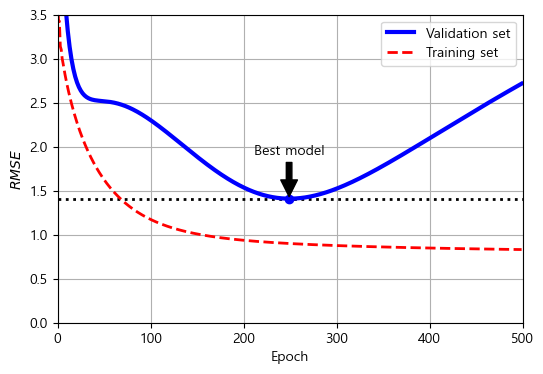

In [47]:
from copy import deepcopy
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

#데이터 생성 및 훈련-검증 분할
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

#다항회귀 적용
preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []  

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = mean_squared_error(y_valid, y_valid_predict, squared=False)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    #훈련 오차를 평가 후 저장
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = mean_squared_error(y_train, y_train_predict, squared=False)
    val_errors.append(val_error)
    train_errors.append(train_error)

#plot 생성
best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate('Best model',
             xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("$RMSE$")
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()
plt.show()

에포크가 진행됨에 따라 알고리즘이 점차 학습되어 훈련 오차와 검증 오차가 줄어든다. 하지만 검증 오차가 다시 상승하는 것을 볼 수 있다. 이는 모델이 훈련 데이터에 과대적합되기 시작했다는 것을 의미한다. 조기 종료는 검증 오차가 최소에 도달하는 즉시 훈련을 멈추는 것이다.

```python
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)

n_epochs = 500
best_valid_rmse = float('inf')

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = mean_squared_error(y_valid, y_valid_predict, squared=False)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)
```

위의 코드는 먼저 다항 변수 term을 추가하고 훈련 세트와 검증 세트 모두에 대해 모든 입력 변수의 스케일을 조정한다. 그런 다음 규제가 없고 학습률이 작은 `SGDRegressor` 모델을 생성한다. 훈련 반복에서 `fit()` 대신 `partial_fit()`을 호출하여 점진적인 학습을 수행한다. 각 에포크에서 검증 오차를 측정해 지금까지 확인된 가장 낮은 RMSE보다 낮으면 `best_model` 변수에 모델의 복사본을 저장한다. 이 구현은 실제로 학습을 중지하지는 않지만 학습 후 최상의 모델로 되돌릴 수 있다.  
`copy.deepcopy()`를 사용하여 모델을 복사한다는 점에 유의해야 한다. 이 함수는 모델의 하이퍼파라미터와 학습된 파라미터를 모두 복사한다. 이와 반대로 `sklearn.base.clone()`은 모델의 하이퍼파라미터만 복사한다.

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● Tip</strong><br>
    각 규제 모델마다 교차 검증을 사용하여 하이퍼파리미터를 자동으로 튜닝해주는 클래스가 존재한다. <code>GridSearchCV</code>를 사용하는 것과 거의 동일하지만 각 모델에 맞게 최적화되어 있다. <code>RigdeCV</code>, <code>LassoCV</code>, <code>ElasticNetCV</code>가 있다.
    </div>

---

## 4.6 로지스틱 회귀

일부 회귀 알고리즘은 분류에서도 사용할 수 있다. **로지스틱 회귀(로짓 회귀)** 는 샘플이 특정 클래스에 속할 확률을 추정하는 데 널리 사용된다. 추정 확률이 주어진 임계값보다 크면 모델은 그 샘플이 해당 클래스에 속한다고 예측한다. 아니면 클래스에 속하지 않는다고 예측한다. 이를 이진 분류기라고 한다.

### 확률 추정

선형 회귀 모델과 같이 로지스틱 회귀 모델은 입력 변수의 가중치 합을 계산한다. 대신 선형 회귀처럼 바로 결과를 출력하지 않고 결과값의 **로지스틱**을 출력한다.
$$
\hat{p}=h_{\theta}(X)=\sigma(\boldsymbol{\theta^Tx})
$$

여기서 $\sigma(\cdot)$은 로지스틱으로, 0과 1 사이의 값을 출력하는 **시그모이드(sigmoid) 함수**이다.
$$
\sigma(t)=\frac{1}{1+exp(-t)}
$$

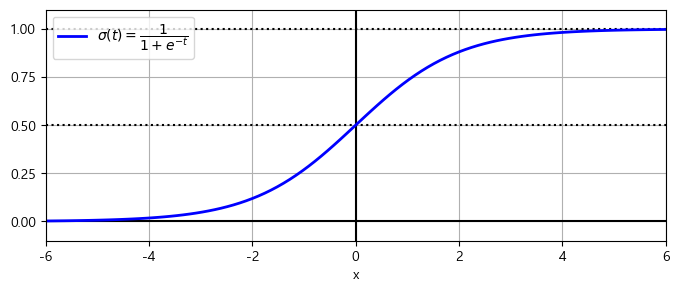

In [62]:
lim = 6
t = np.linspace(-6,6,100)
sigmoid = 1 / (1+np.exp(-t))

plt.figure(figsize=(8, 3))
plt.plot([-lim, lim], [0, 0], "k-")
plt.plot([-lim, lim], [0.5, 0.5], "k:")
plt.plot([-lim, lim], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sigmoid, "b-", linewidth=2, label=r"$\sigma(t) = \dfrac{1}{1 + e^{-t}}$")
plt.xlabel("x")
plt.legend(loc="upper left")
plt.axis([-lim, lim, -0.1, 1.1])
plt.gca().set_yticks([0, 0.25, 0.5, 0.75, 1])
plt.grid()

plt.show()

로지스틱 모델이 샘플 $X$가 양성 클래스에 속할 확률 $\hat{p}=h_{\theta}(X)$를 추정하면 이에 대한 예측 $\hat{y}$를 구할 수 있다.
$$
\hat{y} = \begin{cases} 0 & \text{if } \hat{p} < 0.5 \\ 1 & \text{if } \hat{p} \ge 0.5 \end{cases}  
$$

$t < 0$이면 $\sigma{(t)} < 0.5$이고, $t \ge 0$이면 $\sigma{(t)} \ge 0.5$이므로 기본 임계값인 50% 확률을 사용하는 로지스틱 회귀 모델은 $\boldsymbol{\theta}^TX$가 양수일 때 1이라고 예측하고, 음수일 때 0이라고 예측한다.

사이킷런의 `LogisticRegression`은 클래스 레이블을 반환하는 `predict()` 메서드와 클래스에 속할 확률을 반환하는 `predict_proba()` 메서드를 가지고 있다. `predict()` 메서드는 $\boldsymbol{\theta}^TX$값으로 클래스를 판단하여 결과를 반환하고 `predict_proba()` 메서드는 시그모이드 함수를 적용하여 계산한 확률을 반환한다.

여기서 $t$를 **로짓(logit)** 이라고 부른다. $logit(p)=log(\frac{p}{1-p})$로 정의되는 로짓 함수가 로지스틱 함수의 역함수라는 사실에서 이름을 따왔다.  
실제로 추정 확률 $p$의 로짓을 계산하면 $t$ 값을 얻을 수 있다. 로짓을 **로그-오즈(log-odds)** 라고도 부른다. 로그-오즈는 양성 클래스 추정 확률과 음성 클래스 추정 확률 사이의 로그 비율이기 때문이다.

### 훈련과 비용함수

로지스틱 회귀 모델의 훈련 목적은 양성 샘플 ($y=1$)에 대해서는 높을 확률을 추정하고 음성 샘플 ($y=0$)에 대해서는 낮은 확률을 추정하는 모델의 파라미터 벡터 $\boldsymbol{\theta}$를 찾는 것이다.

이 아이디어를 하나의 훈련 샘플 $X$에 대한 비용함수인 다음 식으로 요약할 수 있다.
$$
c(\boldsymbol{\theta}) = \begin{cases} -log(\hat{p}) & \text{if } \ y=1  \\ -log(1-\hat{p}) & \text{if } \ y=0 \end{cases}
$$

이 비용함수는 $t$가 0에 가까워지면 $-log(t)$가 매우 커지므로 타당한 비용함수라고 볼 수 있다. 그러므로 모델이 양성 샘플을 0에 가까운 확률로 추정하면 비용이 크게 증가한다. 또한 음성 샘플을 1에 가까운 확률로 추정해도 비용이 증가한다. 반면 $t$가 1에 가까우면 $-log(t)$는 0에 가까워진다. 따라서 음성 샘플의 확률을 0에 가깝게 추정하거나 양성 샘플의 확률을 1에 가깝게 추정하면 비용은 0에 가까워질 것이다.

전체 훈련 세트에 대한 비용함수는 모든 훈련 샘플의 비용을 평균낸 것이다. 이를 **로그 손실(log loss)** 라고 부르며 다음과 같이 정의한다.
$$
Loss(\boldsymbol{\theta}) = -\frac{1}{m}\sum_{i=1}^{m}[y^{(i)}log(\hat{p}^{(i)})+(1-y^{(i)})log(1-\hat{p}^{(i)})]
$$

식을 살펴봤을때, 양성 클래스($y^{(i)}=1$)면 $1-y^{(i)}=0$이 되어 $y^{(i)}log(\hat{p}^{(i)})$만 남게 되고, 음성 클래스($y^{(i)}=0$)면 $log(1-\hat{p}^{(i)})$만 남게 된다. 로그 손실을 로지스틱 손실이라고도 부른다.

로그 손실을 사용하면, 샘플이 해당 클래스의 평균을 중심으로 정규분포를 따른다고 가정할 때, 이 손실을 최소화하면 **최대 가능도(Maximum likelihood)가 가장 높은 모델이 된다는 것을 베이즈 추론을 사용하여 수학적으로 증명할 수 있다.** 로그 손실을 사용할 때 이것이 바로 암묵적인 가정이다. 이 가정이 틀릴수록 모델은 더 편향될 것이다. 마찬가지로 선형회귀모델을 학습시키기 위해 $MSE$를 사용할 때는 데이터가 순수한 선형이며 약간의 가우스 잡음이 있다고 가정했다. 따라서 데이터가 선형적이지 않거나 잡음이 가우스 분포를 따르지 않는 경우 모델이 편향될 수 있다.

하지만 이 비용 함수의 최소값을 계산하는 알려진 해는 없다. 하지만 이 비용함수는 볼록 함수이므로 경사하강법(또는 다른 최적화 알고리즘)이 전역 최소값을 찾는 것을 보장한다. 이 비용함수의 $j$번째 모델 파라미터 $\theta_j$에 대해 편미분을 하면 다음과 같다.
$$
\frac{\partial}{\partial \theta_j}Loss(\boldsymbol{\theta})=\frac{1}{m}\sum_{i=1}^{m}(\sigma(\boldsymbol{\theta }^TX^{(i)})-y^{(i)})x^{(i)}_j
$$

이 식은 $MSE$의 편도함수와 매우 비슷해보인다. 각 샘플에 대해 예측 오차를 계산하고 $j$번째 변수값을 곱해서 모든 훈련 샘플에 대해 평균을 낸다. 물론 확률적 경사하강법은 한 번에 하나의 샘플을 사용하고, 미니배치 경사하강법은 한 번에 하나의 미니배치를 사용한다.

### 결정경계

로지스틱 회귀를 설명하기 위해 붓꽃(iris) 데이터셋을 사용한다. 세 개의 품종 Iris-Setosa, Iris-Versicolor, Iris-Virginica이 클래스로 제공되며, 150개의 샘플의 꽃잎, 꽃받침의 너비와 길이를 담고 있다.

꽃잎의 너비를 기반으로 Iris-Versicolor 종을 감지하는 분류기를 만들어본다.

In [64]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


데이터를 분할하고 훈련 세트에서 로지스틱 모델을 훈련시킨다.

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[['petal width (cm)']].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

In [68]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train,y_train);

꽃잎의 너비가 0~3cm인 꽃에 대해 모델의 추정 확률을 계산해본다.

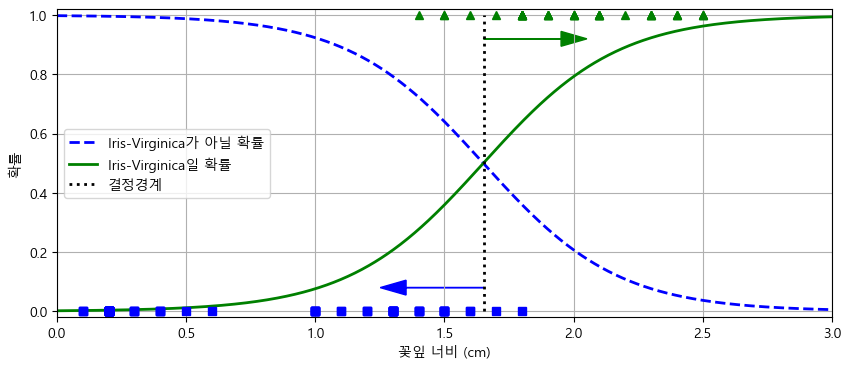

In [72]:
X_new = np.linspace(0,3,1000).reshape(-1,1) #열 벡터로 변환
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:,1] >= 0.5][0,0]

plt.figure(figsize=(10, 4))  # 추가 코드
plt.plot(X_new, y_proba[:,0], 'b--',linewidth=2,
         label='Iris-Virginica가 아닐 확률')
plt.plot(X_new,y_proba[:,1],'g-',linewidth=2, label='Iris-Virginica일 확률')
plt.plot([decision_boundary,decision_boundary],[0,1],'k:',linewidth=2,
         label='결정경계')

plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("꽃잎 너비 (cm)")
plt.ylabel("확률")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()

plt.show()

Iris-Virginica(삼각형)의 꽃잎 너비는 1.45 ~ 2.5 cm에 분포한다. 반면 다른 붓꽃(사각형)은 일반적으로 꽃잎 너비가 더 작다. 약간 중첩되는 부분이 있다. 꽃잎 너비가 2cm 이상인 꽃은 분류기가 Iris-Virginica라고 강하게 확신하며, 1cm 미만이면 Iris-Virginica가 아니라고 확신한다. 이 두 극단 사이에서는 분류가 확실하지 않지만 가장 가능성 높은 클래스를 반환한다. 따라서 양쪽 확률이 똑같이 50%가 되는 1.6cm 근방에서 결정 경계가 만들어진다. 꽃잎 너비가 1.6cm보다 크면 분류기는 Iris-Virginica로 분류하고, 그보다 작으면 아니라고 예측할 것이다.

In [75]:
print(decision_boundary)
print(log_reg.predict([[1.7],[1.5]]))

1.6516516516516517
[ True False]


이번에는 꽃잎 너비와 꽃잎 길이, 두 개의 변수를 사용한다. 훈련이 끝나면 로지스틱 분류기가 이 두 변수를 기반으로 새로운 꽃이 Iris-Virginica인지 확률을 추정한다.

In [77]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(C=2, random_state=42)
log_reg.fit(X_train, y_train);

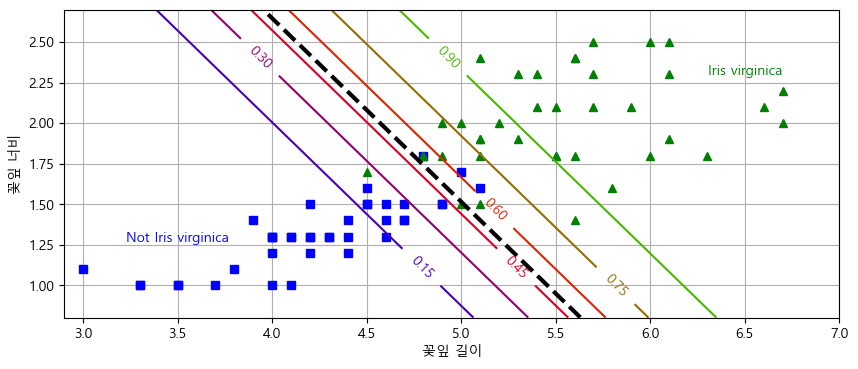

In [81]:
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # 그림의 포인트당 하나의 샘플
y_proba = log_reg.predict_proba(X_new)
zz = y_proba[:, 1].reshape(x0.shape)

# 결정 경계
left_right = np.array([2.9, 7])
boundary = -((log_reg.coef_[0, 0] * left_right + log_reg.intercept_[0])
             / log_reg.coef_[0, 1])

plt.figure(figsize=(10, 4))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
plt.clabel(contour, inline=1)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("꽃잎 길이")
plt.ylabel("꽃잎 너비")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()
plt.show()

점선은 모델이 50% 확률을 추정하는 지점으로, 이 모델의 결정 경계이다. 이 경계는 선형이며, 직선 방정식 $\theta_0+\theta_1x_1+\theta_2x_2$ = 0$을 만족하는 포인트 $X$의 집합이다.

15%(왼쪽 아래)부터 90%(오른쪽 위)까지 나란한 직선들은 모델이 특정 확률을 출력하는 포인트를 나타낸다. 모델은 맨 오른쪽 위의 직선들을 넘는 꽃들을 90% 이상의 확률로 Iris-Virginica라고 판단할 것이다.

다른 선형모델처럼 로지스틱 모델도 $L_1,L_2$ 패널티를 사용하여 규제할 수 있다. 사이킷런은 기본적으로 $L_2$ 패널티를 기본으로 한다.

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● Caution</strong><br>
    사이킷런의 <code>LogisticRegression</code> 모델의 규제 강도를 조절하는 하이퍼파라미터는 다른 선형모델에서 사용되는 <code>alpha</code>가 아니라, 그 역수에 해당하는 <code>C</code>이다. <code>C</code>가 높을수록 모델의 규제가 줄어든다.
    </div>

### 소프트맥스 회귀

로지스틱 모델은 여러 개의 이진 분류기를 훈련시켜 연결하지 않고 **직접 다중 클래스를 지원하도록 일반화**될 수 있다. 이를 **소프트맥스(softmax) 회귀** 또는 **다항 로지스틱(multinomial logistic) 회귀**라고 한다.

샘플 $X$가 주어지면 먼저 소프트맥스 회귀 모델이 각 클래스 $k$에 대한 점수 $S_k(X)$를 계산하고, 그 점수를 **소프트맥스 함수(정규화된 지수 함수)** 를 적용하여 각 클래스의 확률을 추정한다. $S_k(X)$를 계산하는 식은 다음과 같다.
$$
S_k(X)=(\boldsymbol{\theta}^{T})X
$$

각 클래스는 자신만의 파라미터 벡터 $\boldsymbol{\theta}^T$가 있다 .이 벡터들은 **파라미터 행렬 $\Theta$** 에 저장된다. `LogisticRegression`의 `coef_` 속성은 (클래스 수, 변수 수) 크기의 2차원 배열이다. `intercept_` 속성은 클래스 수와 크기가 같은 1차원 배열이다.

샘플 $X$에 대해 각 클래스의 점수가 계산되면 소프트맥스 함수를 통과시켜 클래스 $k$에 속할 확률 $\hat{p}_k$를 추정할 수 있다. 이 함수는 각 점수에 지수함수를 적용한 후 정규화한다. 일반적으로 이 점수를 로짓 또는 로그-오즈라고 부른다.

$$
\hat{p}_k=\sigma(S(X))_k=\frac{exp(S_k(X))}{\sum_{j=1}^{K}exp(S_j(X))}
$$

<center>

| Notation | explanation |
|:--------:|:-----------:|
| $K$      | 클래스의 수   |
| $S(X)$   | 샘플 $X$에 대한 클래스의 점수를 담은 벡터 |
| $\sigma(S(X))_k$ | 샘플 $X$에 대한 각 클래스의 점수가 주어졌을 때 이 샘플이 클래스 $k$에 속할 추정 확률 |

로지스틱 회귀 분류기와 마찬가지로 기본적으로 소프트맥스 회귀 분류기는 다음 식처럼 추정 확률이 가장 높은 클래스를 선택한다.
$$
\hat{y} = \underset{k}{argmax}\ \sigma(S(X))_k=\underset{k}{argmax}\ S_k(X)=\underset{k}{argmax}((\boldsymbol{\theta}^{(k)})^TX)
$$

`argmax` 연산은 함수를 최대화하는 변수의 값을 반환한다. 이 식에서는 추정 확률 $\sigma(S(X))_k$가 최대인 $k$값을 반환한다.

이제 훈련 방법에 대해 살펴본다. 모델이 타겟 클래스에 대해서는 높은 확률을, 다른 클래스에 대해서는 낮은 확률을 추정하도록 만드는 것이 목적이다.

**크로스 엔트로피(Cross entropy)** 비용 함수를 최소화하는 것은 타겟 클래스에 대해 낮은 확률을 예측하는 모델을 억제하므로 이 목적에 부합하다. 크로스 엔트로피는 추정된 클래스의 확률이 타겟 클래스에 얼마나 잘 맞는지 측정하는 용도로 종종 사용된다.

$$
Loss(\Theta)=-\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K} y^{(i)}_k log(\hat{p}^{(i)}_k)
$$

이 식에서 $y^{(i)}_k$는 $i$번째 샘플이 클래스 $k$에 속할 타겟 확률이다. 일반적으로 샘플이 클래스에 속하는지 아닌지에 따라 1 또는 0이 된다. 두 개의 클래스가 있을 때 이 비용함수는 **로그 손실**과 같다.

이 비용함수의 $\boldsymbol{\theta}^{(k)}$에 대한 그래디언트 벡터는 다음과 같다.
$$
\nabla_{\boldsymbol{\theta}^{(k)}}Loss(\Theta)=\frac{1}{m}\sum_{i=1}^{m}(\hat{p}^{(i)}_k-y^{(i)}_k)X^{(i)}
$$

각 클래스에 대한 그래디언트 벡터를 계산할 수 있으므로 비용함수를 최소화하기 위한 파라미터 행렬 $\Theta$를 찾기 위해 경사하강법 또는 다른 최적화 알고리즘을 사용할 수 있다.

소프트맥스 회귀를 사용해 붓꽃을 세 개의 클래스로 분류해본다. 사이킷런의 `LogisticRegression`은 클래스가 둘 이상일 때 자동으로 소프트맥스 함수를 사용한다. `multi_class=multinomial`로 바꾸면 소프트맥스 회귀를 사용할 수 있다. 소프트맥스 회귀를 사용하려면 `solver` 파라미터에 `lbfgs`와 같이 소프트맥스 회귀를 지원하는 알고리즘을 지정해야 한다(자세한 내용은 사이킷런의 온라인 문서 참고). 또한 기본적으로 앞서 언급한 하이퍼파라미터 `C`를 사용하여 조절할 수 있는 $L_2$ 패널티가 적용된다.

In [84]:
X = iris.data[['petal length (cm)','petal width (cm)']].values
y = iris['target']
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)

multi_reg = LogisticRegression(C=30,random_state=42)
multi_reg.fit(X_train,y_train);

꽃잎의 길이가 5cm, 너비가 2cm인 붓꽃을 발견했다고 가정하고 이 붓꽃의 품종이 무엇인지 모델이 예측하면 96%의 확률로 클래스 2에 해당하는 Iris-Virginica를 출력한다.

In [86]:
print(multi_reg.predict([[5,2]]))
print(multi_reg.predict_proba([[5,2]]).round(2))

[2]
[[0.   0.04 0.96]]


다음 그림은 만들어진 결정 경계를 배경색으로 구분하여 나타낸다.

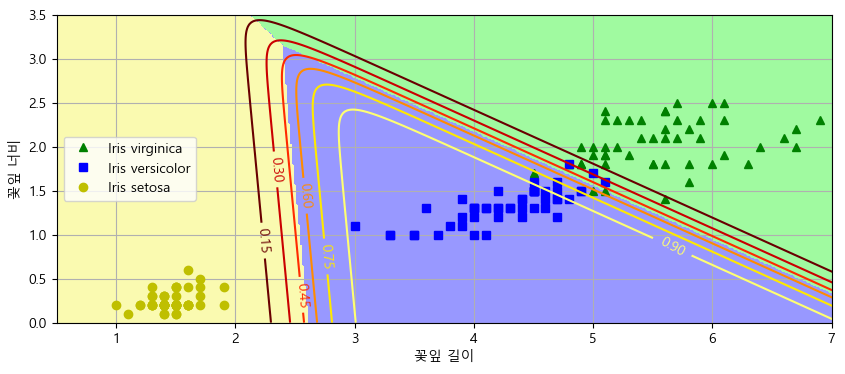

In [89]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = multi_reg.predict_proba(X_new)
y_predict = multi_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("꽃잎 길이")
plt.ylabel("꽃잎 너비")
plt.legend(loc="center left")
plt.axis([0.5, 7, 0, 3.5])
plt.grid()
plt.show()

클래스 사이의 결정 경계가 모두 선형이다. 또한 Iris-Versicolor 클래스에 대한 확률은 곡선으로 나타냈다(즉, 0.3인 직선은 30% 확률 경계를 나타낸다). 이 모델이 추정 확률 50% 이하인 클래스를 예측할 수도 있다는 점을 알아야 한다. 모든 결정 경계가 만나는 지점에서는 모든 클래스가 동일하게 33%의 추정 확률을 가진다.

### 크로스 엔트로피

크로스 엔트로피는 원래 **정보 이론(Information theory)** 에서 유래했다. 매일 날씨 정보를 효율적으로 전달하려 한다고 가정하자. 8가지 정보(맑음, 비 등)가 있다면 $2^3=8$이므로 이 선택 사항을 3비트로 인코딩할 수 있다. 그러나 거의 대부분의 날이 맑음이라면 '맑음'을 하나의 비트(0)로 인코딩하고 다른 일곱 개의 선택 사항을 1로 시작하는 4비트로 표현하는 것이 효율적이다. 크로스 엔트로피는 선택 사항마다 전송한 평균 비트 수를 측정한다. 날씨에 대한 가정이 완벽하다면 크로스 엔트로피는 날씨 자체의 엔트로피와 동일할 것이다. 하지만 이런 가정이 틀렸다면, 즉 비가 자주 온다면 크로스 엔트로피는 **쿨백-라이블러 발산(Kullback-Leibler Divergence,KLD)** 라 불리는 양만큼 커질 것이다.

두 확률 분포 $p$와 $q$ 사이의 크로스 엔트로피는 다음과 같이 정의된다.
$$
H(p,q)= -\sum_{x}^{}p(x)log\ q(x)
$$